# Sentinel-5P Methane Level-2

* **Products used:** 
[s5p_tropomi_l2_ch4](https://explorer.digitalearth.africa/products/s5p_tropomi_l2_ch4)
[s5p_tropomi_l2_cloud](https://explorer.digitalearth.africa/products/s5p_tropomi_l2_cloud)
[ERA5](https://registry.opendata.aws/ecmwf-era5/)

## Background

Sentinel-5P is a European Earth observation satellite launched in 2017 under the Copernicus Programme to monitor atmospheric composition and air quality. It carries the TROPOspheric Monitoring Instrument (TROPOMI), a hyperspectral sensor that measures trace gases such as methane (CH₄), nitrogen dioxide (NO₂), ozone (O₃), sulfur dioxide (SO₂), and carbon monoxide (CO). Methane retrievals are primarily derived from shortwave infrared (SWIR) spectral absorption measurements, enabling global observations of atmospheric methane concentrations with daily revisit capability[Sentinel-5 Precursor Level 2 Methane - Copernicus](https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-5P/Sentinel-5P_data_used_in_new_methane_detection_system).

Methane is the second most important anthropogenic greenhouse gas after carbon dioxide and has a significantly higher warming potential over short time scales. Sentinel-5P methane products provide column-averaged dry-air mole fractions of methane (XCH₄), allowing researchers to monitor methane sources, sinks, and atmospheric transport processes at regional to global scales. The high spatial and temporal resolution of TROPOMI enables the identification of methane hotspots associated with oil and gas production, coal mining, landfills, wetlands, agriculture, and biomass burning [Sentinel-5 Precursor Level 2 Methane - Copernicus](https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-5P/Sentinel-5P_data_used_in_new_methane_detection_system).

The Sentinel-5P methane dataset has become an important resource for climate science, greenhouse gas inventories, and environmental policy assessment. Its near-daily global coverage supports the detection of large methane leaks and “super-emitters,” improving the understanding of emission dynamics and supporting mitigation strategies. The dataset is also widely integrated with higher-resolution satellite observations, atmospheric models, and ground-based measurements to enhance emission quantification and validation. This capability has significantly advanced operational methane monitoring for climate change research and international climate reporting frameworks [Sentinel-5P data used in new methane detection system](https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-5P/Sentinel-5P_data_used_in_new_methane_detection_system).

### Sentinel-5P TROPOMI Level-2 Methane
2. **Methane (CH₄) Column-Averaged Mixing Ratio** measures the vertically integrated concentration of methane in the atmosphere and is used to identify major greenhouse gas emission sources and support climate change research.
***

## Description

This notebook will cover following topics:

1. Inspecting the products and measurements available in the datacube
2. Loading Sentinel-5P_*** Datasets.
3. Plotting the results
4. ERA5 Climate Gridded Data

***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell.

### Load packages
Import Python packages that are used for the analysis.

In [1]:
%matplotlib inline

import numpy as np
import xarray as xr
import pandas as pd
import datacube
import geopandas as gpd
from odc.geo.geom import Geometry
from IPython.display import Markdown, display

from deafrica_tools.plotting import display_map
from deafrica_tools.areaofinterest import define_area
from deafrica_tools.load_era5 import load_era5


### Connect to the datacube

Connect to the datacube so we can access DE Africa data.

In [2]:
dc = datacube.Datacube(app="Sentinel_5P_methane")

### List measurements
Run the cell below to inspect he measurments of s5p_tropomi_l2_ch4, using the datacube's `list_measurements` functionality.

In [3]:
product = "s5p_tropomi_l2_ch4"
measurements = dc.list_measurements()
display(Markdown("**The table below lists the measurements available for the data**"))
measurements.loc[product]

**The table below lists the measurements available for the data**

,name,dtype,units,nodata,aliases,flags_definition,add_offset,scale_factor
measurement,,,,,,,,
CH4,CH4,float32,ppb,-9999.0,NaN,NaN,0.0,1.0
dataMask,dataMask,uint8,1,255.0,NaN,NaN,0.0,1.0


### Analysis parameters

The following cell sets the parameters, which define the area of interest to conduct the analysis over.
#### Select location
To define the area of interest, there are two methods available:

1. By specifying the latitude, longitude, and buffer, or separate latitude and longitude buffers, this method allows you to define an area of interest around a central point. You can input the central latitude, central longitude, and a buffer value in degrees to create a square area around the center point. For example, `lat = 10.338`, `lon = -1.055`, and `buffer = 0.1` will select an area with a radius of 0.1 square degrees around the point with coordinates `(10.338, -1.055)`. 
    
    Alternatively, you can provide separate buffer values for latitude and longitude for a rectangular area. For example, `lat = 10.338`, `lon = -1.055`, and `lat_buffer = 0.1` and`lon_buffer = 0.08` will select a rectangular area extending 0.1 degrees north and south, and 0.08 degrees east and west from the point `(10.338, -1.055)`.

   For reasonable loading times, set the buffer as `0.1` or lower.

3. By uploading a polygon as a `GeoJSON or Esri Shapefile`. If you choose this option, you will need to upload the geojson or ESRI shapefile into the Sandbox using Upload Files button <img align="top" src="../Supplementary_data/upload_files_icon.png"> in the top left corner of the Jupyter Notebook interface. ESRI shapefiles must be uploaded with all the related files `(.cpg, .dbf, .shp, .shx)`. Once uploaded, you can use the shapefile or geojson to define the area of interest. Remember to update the code to call the file you have uploaded.

To use one of these methods, you can uncomment the relevant line of code and comment out the other one. To comment out a line, add the `"#"` symbol before the code you want to comment out. By default, the first option which defines the location using latitude, longitude, and buffer is being used.

**If running the notebook for the first time**, keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.

The example focuses on the Niger Delta region of Nigeria, one of Africa’s most significant methane emission hotspots associated with oil and gas production, gas flaring, pipelines, refineries, wetlands, and urban-industrial activities. The region exhibits strong atmospheric methane signals detectable by Sentinel-5P TROPOMI, alongside emissions from biomass burning and other trace gases linked to energy production and environmental degradation. Due to persistent industrial activity and relatively consistent atmospheric observations during the dry season, the Niger Delta provides an ideal demonstration site for evaluating the capabilities of Sentinel-5P Level-2 methane products under complex and dynamic environmental conditions.

**To run the notebook for a different area**, make sure Sentinel-5 Precursor’s TROPOMI data is available for the chosen area using the [DEAfrica Explorer](https://explorer.digitalearth.africa).

In [4]:
# Method 1: Specify the latitude, longitude, and buffer)
aoi = define_area(lat=5.5, lon=6.5, buffer=1)

# Method 2: Use a polygon as a GeoJSON or Esri Shapefile. 
# aoi = define_area(vector_path='aoi.shp')

#Create a geopolygon and geodataframe of the area of interest
geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")
geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

# Get the latitude and longitude range of the geopolygon
lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])
lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

In [5]:
display_map(x=lon_range, y=lat_range)

### Accessing Sentinel 5P data through DE Africa

Now that we know what products and measurements are available for the product, we can load data from the datacube using `dc.load`. We will load data from spectral satellite bands. By specifying `output_crs='EPSG:4326'` and `resolution=(-0.01, 0.01`), we are loading data in its native projection and resolution. Finally, `group_by='solar_day'` ensures that overlapping images taken within seconds of each other as the satellite passes over are combined into a single time step in the data. The query defined below will be used for all the other products.

In [6]:
time_start = "2025-01-10"
time_end = "2025-01-11"
query = {
    'x': (lon_range),
    'y': (lat_range),
    'time':(time_start, time_end),
    'output_crs': 'EPSG:4326',
    'resolution': (-0.01, 0.01)}

In [7]:
query

{'x': (np.float64(5.5), np.float64(7.5)),
 'y': (np.float64(4.5), np.float64(6.5)),
 'time': ('2025-01-10', '2025-01-11'),
 'output_crs': 'EPSG:4326',
 'resolution': (-0.01, 0.01)}

#### 2. Sentinel-5P TROPOMI Level-2 Methane (CH₄) Column-Averaged Mixing Ratio

Sentinel-5P TROPOMI Level-2 Methane (CH₄) Column-Averaged Mixing Ratio is a satellite product from Sentinel-5 Precursor’s TROPOMI that measures the vertically integrated amount of methane in the atmosphere by analyzing reflected shortwave-infrared sunlight. It is used to detect and map methane emission hotspots, quantify regional sources from oil and gas operations, agriculture and wetlands, monitor trends in a major greenhouse gas, and support climate policy and mitigation efforts.

In [8]:
ds_l2_ch4 = dc.load(product='s5p_tropomi_l2_ch4',
                    group_by="solar_day", 
                    **query)

ds_l2_ch4

<xarray.Dataset> Size: 403kB
Dimensions:      (time: 2, latitude: 200, longitude: 200)
Coordinates:
  * time         (time) datetime64[ns] 16B 2025-01-10T06:09:18.500000 2025-01...
  * latitude     (latitude) float64 2kB 6.495 6.485 6.475 ... 4.525 4.515 4.505
  * longitude    (longitude) float64 2kB 5.505 5.515 5.525 ... 7.475 7.485 7.495
    spatial_ref  int32 4B 4326
Data variables:
    CH4          (time, latitude, longitude) float32 320kB 1.944e+03 ... nan
    dataMask     (time, latitude, longitude) uint8 80kB 1 1 1 1 1 ... 0 0 0 0 0
Attributes:
    crs:           EPSG:4326
    grid_mapping:  spatial_ref

#### Masking

Before visualisation, we use the `dataMask` band to mask values affected by cloud or other issues. The code below keeps data for pixels where the data mask value is 1.

In [9]:
ds_l2_ch4 = ds_l2_ch4.where(ds_l2_ch4.dataMask == 1)

#### Visualising the band

Methane (CH₄) is a potent greenhouse gas emitted by wetlands, livestock, oil and gas production, landfills, and rice fields. Sentinel-5P measures CH₄ in parts per billion (PPB). It plays a major role in climate warming and atmospheric chemical reactions.

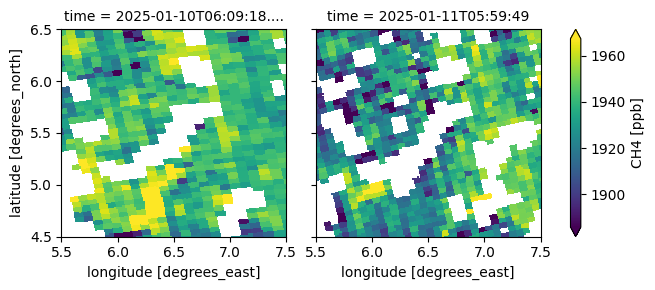

In [10]:
ds_l2_ch4['CH4'].plot(robust=True, col="time")

## Load ERA5 Climate Gridded Data

ERA5 surface pressure is required in Sentinel-5P methane analysis because methane retrievals are provided as column-averaged dry-air mole fractions (XCH₄) in parts per billion (ppb), which depend on the total atmospheric air mass and pressure structure above the Earth’s surface. Surface pressure data enables the conversion of methane concentrations from ppb into physical quantities such as molar concentration, mass density, and total methane mass in tonnes using atmospheric relationships such as the ideal gas law, while also improving consistency and reducing uncertainties associated with elevation and meteorological variability.

The cell below loads the surface pressure variable for the study area.

In [11]:
# Loading surface pressure from ERA 5
surface_pressure = load_era5('surface_pressure', lat_range, lon_range, query['time'], chunks=None)

Opening ERA5 Zarr dataset...
Variable: surface_pressure
Mapped ERA5 name: surface_pressure
Time: 2025-01-10 to 2025-01-11
Latitude: 4.5 to 6.5
Longitude: 5.5 to 7.5
Selecting time range...
Normalising longitude coordinates...
Selecting AOI...
Subset size: {'time': 48, 'latitude': 9, 'longitude': 9}
Resampling to 1D using mean...
ERA5 loading complete.


### Converting Methane units from ppb to Total Atmospheric Gas Mass (Tonnes)

Methane products provide atmospheric trace-gas measurements as **vertical column-averaged** dry-air mole fractions in units of **parts per billion (ppb)**. These values represent the average concentration of methane within the atmospheric column above each satellite pixel, normalized by the amount of dry air.

#### Why Compute Tonnes?

Expressing gas amounts in tonnes provides a **policy-relevant and intuitive metric** for:

- Evaluating emission sources (urban, industrial, biomass burning, wetlands)
- Quantifying atmospheric loading during pollution episodes
- Comparing different gases on the same scale
- Reporting mass-based metrics for climate and air-quality frameworks
- Supporting SDG and AU Agenda 2063 environmental assessments

Converting trace-gas columns into physically meaningful mass values allows researchers and decision-makers to translate satellite observations into actionable insights.

---

#### Molecular Weights Used in the Conversion

The molecular weight determines how many grams one mole of a gas weighs:

| Gas | Molecular Weight (g/mol) |
|-----|---------------------------|
| CH₄ (Methane) | 16.04 |

The value is provided to the conversion function so that any Sentinel-5P gas product can be processed consistently.

---

The function below performs the full conversion from **Sentinel-5P TROPOMI Level-2 methane vertical column data** (provided in **ppb**) into **total atmospheric mass expressed in tonnes** for your area of interest (AOI). 

To run the calculation, you only need to supply:

1. **The gas column variable** from your dataset  
   - `ch4_column` is in ppb, it must be converted to an appropriate column amount (e.g., mol/m²) before converting it to tonnes.

The function automatically:
- Computes pixel areas from the latitude/longitude grid  
- Applies cloud masking if needed  
- Converts  ppb → tonnes  
- Sums across all valid pixels  

This allows you to transform satellite-observed column densities into a meaningful physical metric (tonnes) for environmental analysis, climate studies, emission tracking, and reporting.

In [12]:
# -----------------------------
# Constants
# -----------------------------
G = 9.80665
M_AIR = 0.0289652   # kg/mol
M_CH4 = 0.01604     # kg/mol
R_EARTH = 6371008.8 # m

# -----------------------------
# Helpers
# -----------------------------
def rename_latlon(ds):
    ren = {}
    if "latitude" in ds.dims:
        ren["latitude"] = "lat"
    if "longitude" in ds.dims:
        ren["longitude"] = "lon"
    if "latitude" in ds.coords:
        ren["latitude"] = "lat"
    if "longitude" in ds.coords:
        ren["longitude"] = "lon"
    return ds.rename(ren) if ren else ds

def gridcell_area_m2(lat, lon):
    """
    Approximate area for a regular lat/lon grid.
    Returns DataArray with dims (lat, lon).
    """
    lat_rad = np.deg2rad(lat.values)
    lon_rad = np.deg2rad(lon.values)

    dlat = np.abs(np.gradient(lat_rad))
    dlon = np.abs(np.gradient(lon_rad))

    area = (R_EARTH ** 2) * np.outer(np.cos(lat_rad) * dlat, dlon)

    return xr.DataArray(
        area,
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name="pixel_area_m2",
        attrs={"units": "m2"},
    )

In [13]:
# Make sure the dataset have the same lat and lon name
ds_l2_ch4 = rename_latlon(ds_l2_ch4)
surface_pressure = rename_latlon(surface_pressure)

#select only th CH4 variable
ds_l2_ch4 = ds_l2_ch4["CH4"]

The code below interpolates ERA5 surface pressure data to match the spatial coordinates (latitude and longitude) and observation times of the Sentinel-5P methane dataset using the nearest available values. This ensures that the surface pressure information is aligned with each methane observation for accurate atmospheric and methane mass calculations.

In [14]:
sp_pressure = surface_pressure["surface_pressure"].interp(
    time=ds_l2_ch4.time,
    lat=ds_l2_ch4.lat,
    lon=ds_l2_ch4.lon,
    method="nearest",
    kwargs={"fill_value": "extrapolate"}
)

The code calculates the surface area of each Sentinel-5P methane grid cell in square metres based on the dataset’s latitude and longitude coordinates. These grid-cell areas are required for converting methane concentrations into total methane mass or emission estimates in physical units such as tonnes.

In [15]:
area = gridcell_area_m2(ds_l2_ch4.lat, ds_l2_ch4.lon)

The cell below estimates excess atmospheric methane mass by first determining a background methane concentration from the 5th percentile of the Sentinel-5P methane observations and then calculating methane enhancement above this background level. The enhanced methane concentrations are converted from parts per billion (ppb) into methane mass per pixel in tonnes using surface pressure and pixel area, after which the total methane mass is computed by summing all pixels across the study area.

In [16]:
# estimate a simple per-time background; replace with your preferred plume background
background = ds_l2_ch4.quantile(0.05, dim=("lat", "lon"), skipna=True)
delta_ppb = ds_l2_ch4 - background

tonnes_per_pixel = (
    delta_ppb * 1e-9
    * (sp_pressure / G)
    * (M_CH4 / M_AIR)
    * area
    / 1000.0
)


total_tonnes = tonnes_per_pixel.sum(dim=["lat", "lon"], skipna=True)

Additional conversion to kg/m2 is calculated in the cell below because tonnes represent the total methane mass over the entire study area, whereas kg/m2 standardizes the methane amount relative to surface area. This area-normalized unit enables meaningful comparisons between regions of different sizes, supports spatial interpretation of methane intensity and distribution, and aligns better with atmospheric mass-loading analyses commonly used in environmental and climate studies.

In [17]:
# Total study area in m²
total_area_m2 = area.sum().item()

df_tonnes = (
    total_tonnes
    .to_dataframe(name="tonnes")
    .reset_index()
    .rename(columns={"time": "timestep"})
)

# Round tonnes
df_tonnes["tonnes"] = df_tonnes["tonnes"].round(2)

# Convert tonnes -> kg/m²
df_tonnes["kg_m2"] = ((df_tonnes["tonnes"] * 1000) / total_area_m2)

In [18]:
display(df_tonnes)

print('----')
print('tonnes → total methane mass over the study area')
print('kg_m2 → average methane mass loading per square metre over the study area')

,timestep,spatial_ref,quantile,tonnes,kg_m2
0,2025-01-10 06:09:18.500,4326,0.05,5412.71,0.000110
1,2025-01-11 05:59:49.000,4326,0.05,7115.88,0.000145


----
tonnes → total methane mass over the study area
kg_m2 → average methane mass loading per square metre over the study area


## Conclusion

Through Digital Earth Africa, methane data from the Sentinel-5P TROPOMI instrument are transforming access to atmospheric greenhouse gas information across Africa by providing analysis-ready observations of atmospheric methane concentrations. DE Africa reduces technical barriers to satellite data access through open data services, cloud-based processing, and scalable analytical tools, enabling researchers, institutions, and governments to monitor methane emissions from sources such as oil and gas activities, wetlands, landfills, agriculture, and biomass burning without requiring advanced computational infrastructure. Converting methane concentrations from parts per billion (ppb) into physical quantities such as tonnes is important because it enables estimation of the actual methane mass released into the atmosphere, supports greenhouse gas inventories and emission reporting, and improves climate mitigation planning, environmental governance, and policy decision-making aligned with the United Nations Sustainable Development Goals and the African Union Agenda 2063.

---

## Additional information

<b> License </b> The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

<b> Contact </b> If you need assistance, please post a question on the [DE Africa Slack channel](https://digitalearthafrica.slack.com/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).

If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

<b> Compatible datacube version </b>

In [19]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [20]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-05-14'